### Supplementary 

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import string
import math
from scipy.stats import norm
from scipy.special import expit
from scipy.special import log_ndtr
from mpl_toolkits.axes_grid1 import make_axes_locatable


df_sim_common = pd.read_csv("data/df_sim_common.csv")
df_tonkin_drop_zero_common = pd.read_csv("data/df_tonkin_drop_zero_common.csv")
df_mccrone_drop_zero_common = pd.read_csv("data/df_mccrone_drop_zero_common.csv")

ton = pd.read_csv("data/Table_S2.csv")


#### Figure S1 

In [35]:
d = np.load("heatmap_results/mock_sigma_06_logL_fitexp_nu400.npz")
logL_06_nu400_fitexp, F2_06_nu400 = d["logL"], float(d["f2_mean"])

d = np.load("heatmap_results/mock_sigma_10_logL_fitexp_nu400.npz")
logL_10_nu400_fitexp, F2_10_nu400 = d["logL"], float(d["f2_mean"])

d = np.load("heatmap_results/mock_sigma_14_logL_fitexp_nu400.npz")
logL_14_nu400_fitexp, F2_14_nu400 = d["logL"], float(d["f2_mean"])

logL_06_nu400_flat = np.load("heatmap_results/mock_sigma_06_logL_nu400_flat.npy")
logL_10_nu400_flat = np.load("heatmap_results/mock_sigma_10_logL_nu400_flat.npy")
logL_14_nu400_flat = np.load("heatmap_results/mock_sigma_14_logL_nu400_flat.npy")

logL_06_nu400_exp = np.load("heatmap_results/mock_sigma_06_logL_exp_nu400.npy")
logL_10_nu400_exp = np.load("heatmap_results/mock_sigma_10_logL_exp_nu400.npy")
logL_14_nu400_exp = np.load("heatmap_results/mock_sigma_14_logL_exp_nu400.npy")

logL_06_nu400_nom1 = np.load("heatmap_results/mock_sigma_06_logL_nom1_nu400.npy")
logL_10_nu400_nom1 = np.load("heatmap_results/mock_sigma_10_logL_nom1_nu400.npy")
logL_14_nu400_nom1 = np.load("heatmap_results/mock_sigma_14_logL_nom1_nu400.npy")

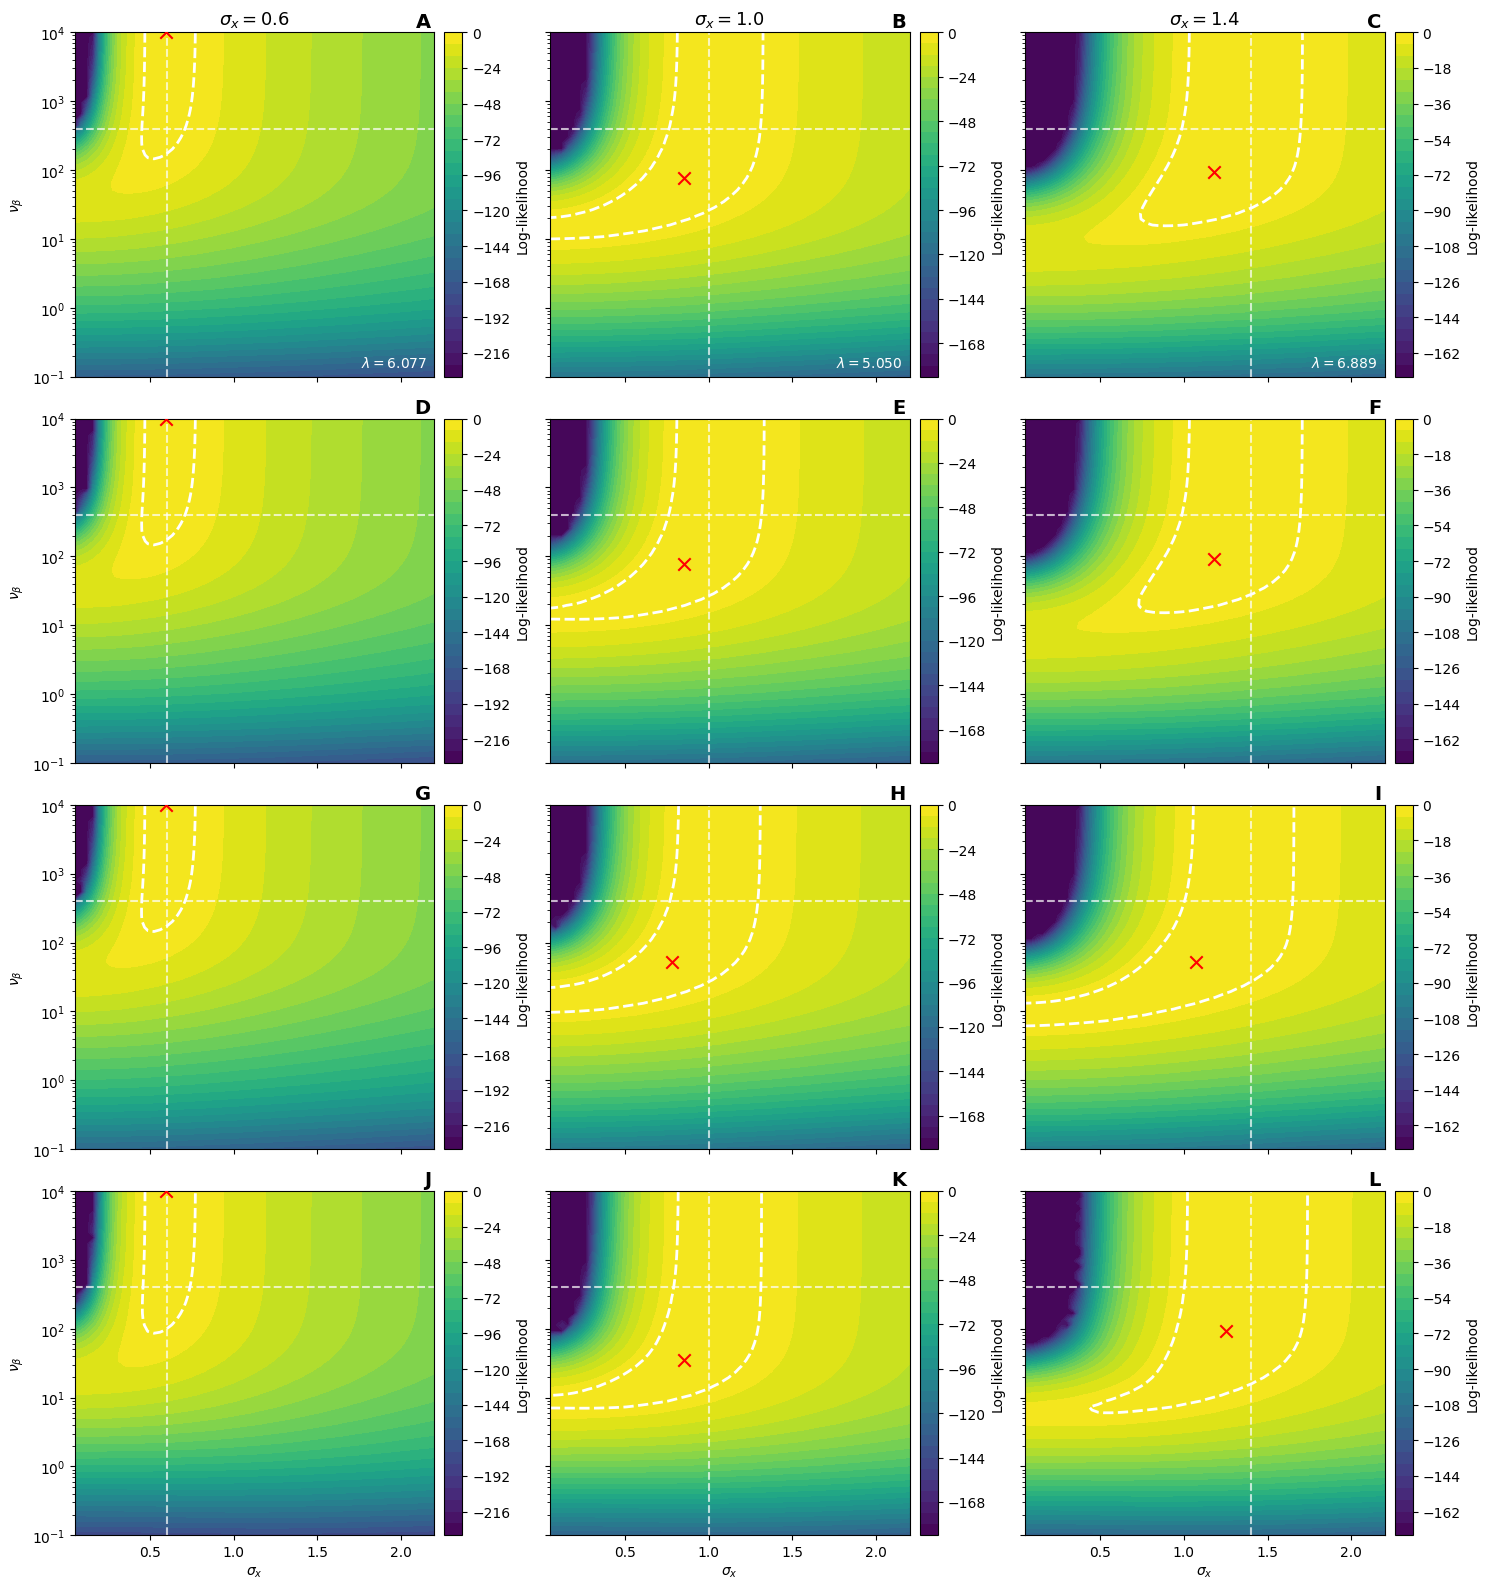

In [36]:
sigma_grid = np.linspace(0.05, 2.2, 60)
nu_grid    = np.logspace(-1, 4, 60)
threshold_95 = -stats.chi2.ppf(0.95, df=2) / 2
T_days     = 24 / 24.0   # 24 h expressed in days


sig_tags = [("06", 0.6), ("10", 1.0), ("14", 1.4)]
res = {}
for tag, _ in sig_tags:
    d = np.load(f"heatmap_results/mock_sigma_{tag}_logL_fitexp_nu400.npz")
    res[("fitexp", tag)] = (d["logL"], float(d["f2_mean"]))
    res[("exp",    tag)] = (np.load(f"heatmap_results/mock_sigma_{tag}_logL_exp_nu400.npy"),  None)
    res[("flat",   tag)] = (np.load(f"heatmap_results/mock_sigma_{tag}_logL_nu400_flat.npy"), None)
    res[("nom1",   tag)] = (np.load(f"heatmap_results/mock_sigma_{tag}_logL_nom1_nu400.npy"), None)

row_names = ["fitexp", "exp", "flat", "nom1"]

# rows = weighting, cols = sigma; entries are (row_label, true_sigma, logL, F2)
datasets_heatmap = [
    [(name, s, *res[(name, tag)]) for tag, s in sig_tags]
    for name in row_names
]

true_nu = 400.0          # all panels are the nu=400 mocks
LOGL_FLOOR = -160

# ---------------- plot ----------------
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for row in range(4):
    for col in range(3):
        ax = axes[row, col]
        panel_label = chr(ord("A") + row * 3 + col)
        ax.text(
            0.99,1.06,
            panel_label,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=14,
            fontweight="bold",
            color="black"
        )
        row_label, true_sigma, logL_raw, F2 = datasets_heatmap[row][col]

        logL = np.copy(logL_raw)
        logL[logL < LOGL_FLOOR] = LOGL_FLOOR
        logL_centered = logL - np.max(logL)

        max_idx   = np.unravel_index(np.argmax(logL), logL.shape)
        sigma_hat = sigma_grid[max_idx[0]]
        nu_hat    = nu_grid[max_idx[1]]

        cs = ax.contourf(sigma_grid, nu_grid, logL_centered.T,
                         levels=30, cmap="viridis")

        if not np.all(logL_centered == 0):
            ax.contour(sigma_grid, nu_grid, logL_centered.T,
                       levels=[threshold_95], colors="white",
                       linestyles="dashed", linewidths=2)

        ax.axhline(true_nu,    color="white", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.axvline(true_sigma, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.scatter(sigma_hat, nu_hat, color="red", marker="x", s=80, zorder=10,
                   label=fr"MLE: $\sigma$={sigma_hat:.2f}, $\nu$={nu_hat:.1f}")
        # ax.legend(loc="upper right", fontsize=8, framealpha=0.4,labelcolor="white", facecolor="black")

        if F2 is not None:
            ax.text(0.98, 0.02, fr"$\lambda={1/F2:.3f}$", color="white",
                    fontsize=10, ha="right", va="bottom", transform=ax.transAxes)

        ax.set_yscale("log")
        ax.set_xlim(sigma_grid[0], sigma_grid[-1])
        ax.set_ylim(nu_grid[0], nu_grid[-1])

        # column headers / row headers
        if row == 0:
            ax.set_title(fr"$\sigma_x = {true_sigma}$", fontsize=13)
        if row == 3:
            ax.set_xlabel(r"$\sigma_x$")
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(r"$\nu_{\beta}$")
            # ax.text(-0.28, 0.5, row_label, transform=ax.transAxes, fontsize=13, fontweight="bold", rotation=90,ha="center", va="center")
        else:
            ax.set_yticklabels([])

        cax  = make_axes_locatable(ax).append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(cs, cax=cax)
        cbar.set_label("Log-likelihood")

plt.tight_layout()
plt.show()

#### Figure S2

In [40]:
d = np.load("heatmap_results/mock_sigma_06_logL_fitexp_nu10.npz")
logL_06_nu10_fitexp, F2_06_nu10 = d["logL"], float(d["f2_mean"])

d = np.load("heatmap_results/mock_sigma_10_logL_fitexp_nu10.npz")
logL_10_nu10_fitexp, F2_10_nu10 = d["logL"], float(d["f2_mean"])

d = np.load("heatmap_results/mock_sigma_14_logL_fitexp_nu10.npz")
logL_14_nu10_fitexp, F2_14_nu10 = d["logL"], float(d["f2_mean"])

sigma_grid = np.linspace(0.05, 2.2, 60)
nu_grid    = np.logspace(-1, 4, 60)

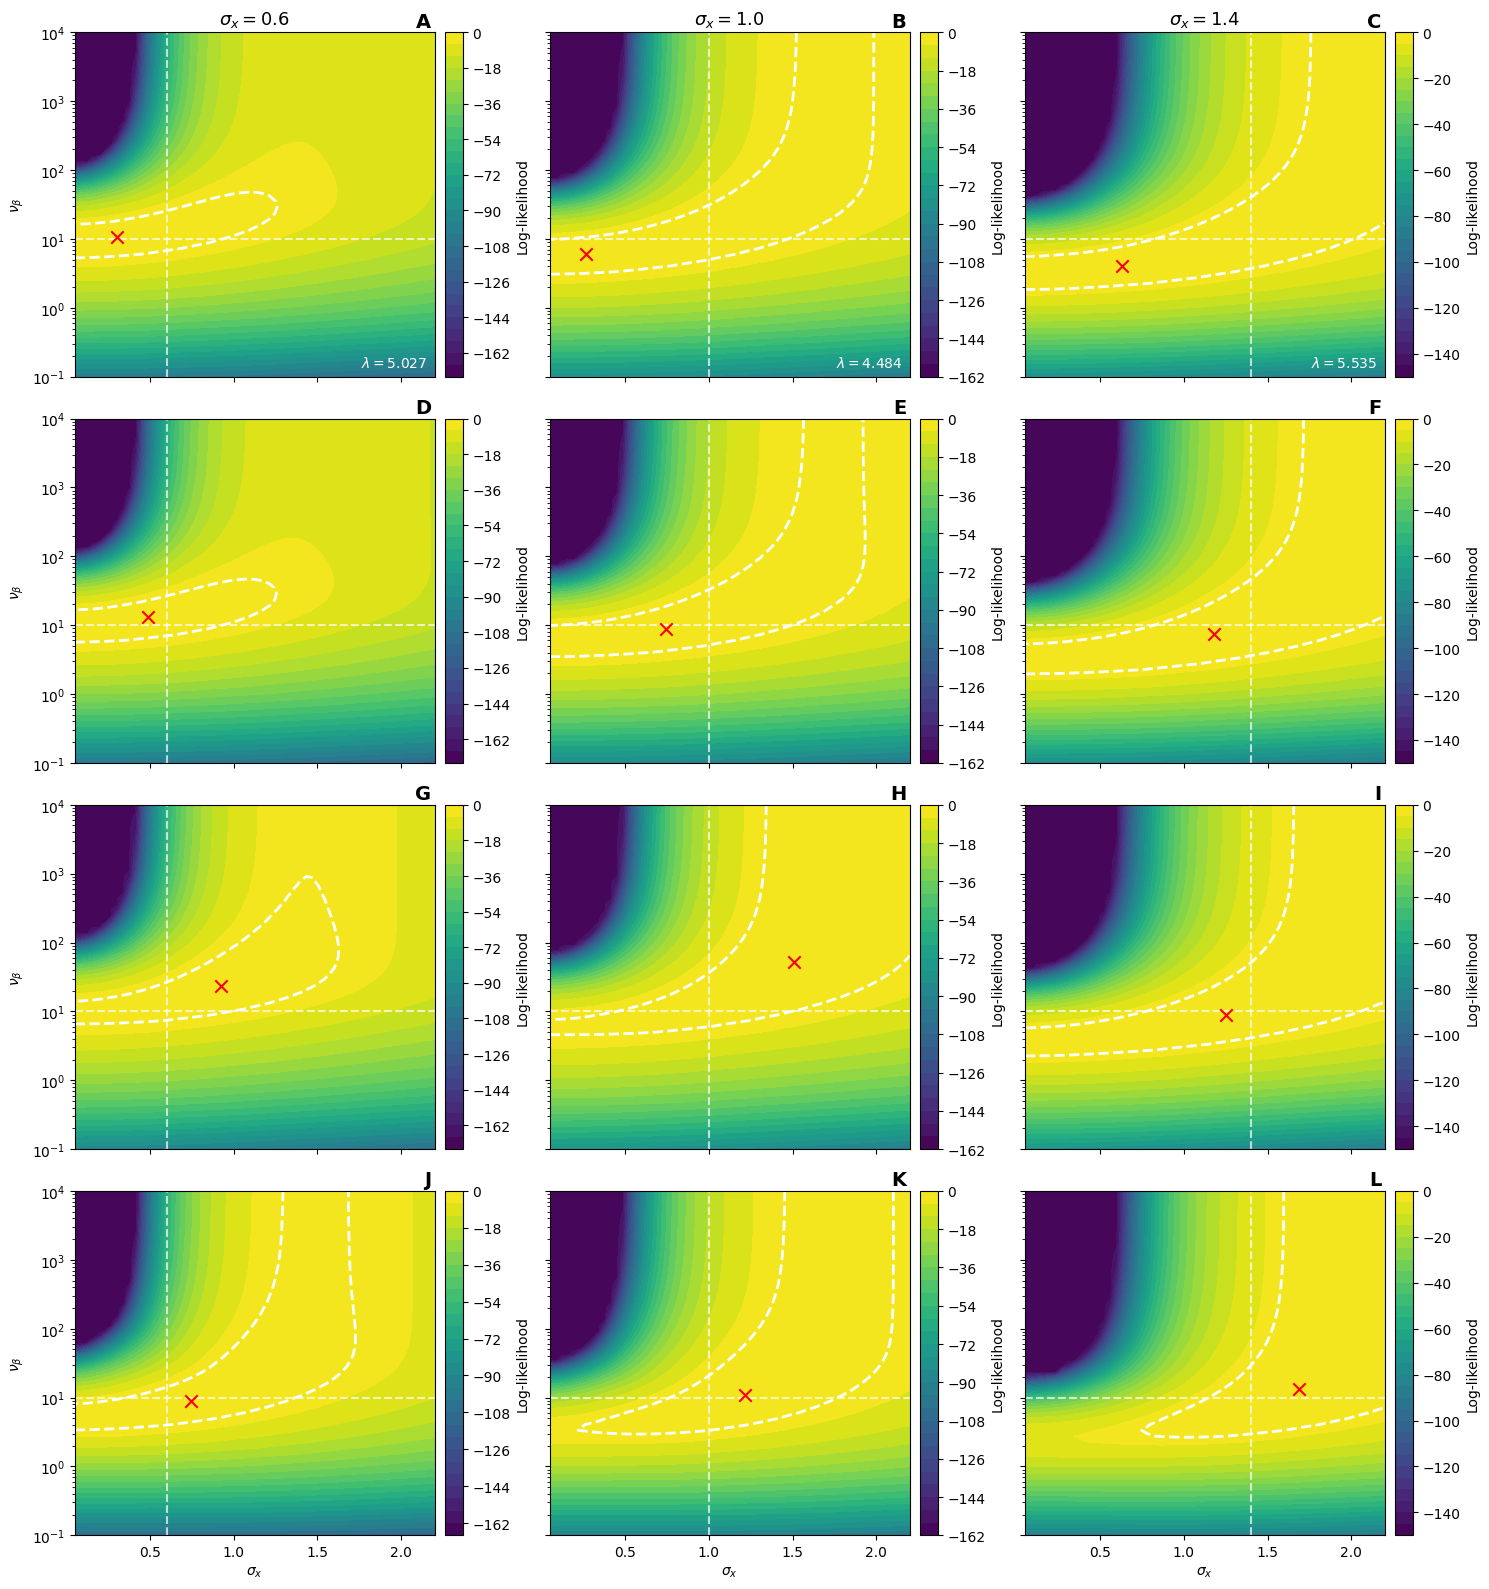

In [41]:

# ---------------- load ----------------
sig_tags = [("06", 0.6), ("10", 1.0), ("14", 1.4)]
res = {}
for tag, _ in sig_tags:
    d = np.load(f"heatmap_results/mock_sigma_{tag}_logL_fitexp_nu10.npz")
    res[("fitexp", tag)] = (d["logL"], float(d["f2_mean"]))
    res[("exp",    tag)] = (np.load(f"heatmap_results/mock_sigma_{tag}_logL_exp_nu10.npy"),  None)
    res[("flat",   tag)] = (np.load(f"heatmap_results/mock_sigma_{tag}_logL_nu10_flat.npy"), None)
    res[("nom1",   tag)] = (np.load(f"heatmap_results/mock_sigma_{tag}_logL_nom1_nu10.npy"), None)

row_names = ["fitexp", "exp", "flat", "nom1"]

# rows = weighting, cols = sigma; entries are (row_label, true_sigma, logL, F2)
datasets_heatmap = [
    [(name, s, *res[(name, tag)]) for tag, s in sig_tags]
    for name in row_names
]

true_nu = 10.0          # all panels are the nu=10 mocks
LOGL_FLOOR = -160

# ---------------- plot ----------------
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for row in range(4):
    for col in range(3):
        ax = axes[row, col]
        panel_label = chr(ord("A") + row * 3 + col)
        ax.text(
            0.99,1.06,
            panel_label,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=14,
            fontweight="bold",
            color="black"
        )
        row_label, true_sigma, logL_raw, F2 = datasets_heatmap[row][col]

        logL = np.copy(logL_raw)
        logL[logL < LOGL_FLOOR] = LOGL_FLOOR
        logL_centered = logL - np.max(logL)

        max_idx   = np.unravel_index(np.argmax(logL), logL.shape)
        sigma_hat = sigma_grid[max_idx[0]]
        nu_hat    = nu_grid[max_idx[1]]

        cs = ax.contourf(sigma_grid, nu_grid, logL_centered.T,
                         levels=30, cmap="viridis")

        if not np.all(logL_centered == 0):
            ax.contour(sigma_grid, nu_grid, logL_centered.T,
                       levels=[threshold_95], colors="white",
                       linestyles="dashed", linewidths=2)

        ax.axhline(true_nu,    color="white", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.axvline(true_sigma, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.scatter(sigma_hat, nu_hat, color="red", marker="x", s=80, zorder=10,
                   label=fr"MLE: $\sigma$={sigma_hat:.2f}, $\nu$={nu_hat:.1f}")
        # ax.legend(loc="upper right", fontsize=8, framealpha=0.4,labelcolor="white", facecolor="black")

        if F2 is not None:
            ax.text(0.98, 0.02, fr"$\lambda={1/F2:.3f}$", color="white",
                    fontsize=10, ha="right", va="bottom", transform=ax.transAxes)

        ax.set_yscale("log")
        ax.set_xlim(sigma_grid[0], sigma_grid[-1])
        ax.set_ylim(nu_grid[0], nu_grid[-1])

        # column headers / row headers
        if row == 0:
            ax.set_title(fr"$\sigma_x = {true_sigma}$", fontsize=13)
        if row == 3:
            ax.set_xlabel(r"$\sigma_x$")
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(r"$\nu_{\beta}$")
            # ax.text(-0.28, 0.5, row_label, transform=ax.transAxes, fontsize=13, fontweight="bold", rotation=90,ha="center", va="center")
        else:
            ax.set_yticklabels([])

        cax  = make_axes_locatable(ax).append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(cs, cax=cax)
        cbar.set_label("Log-likelihood")

plt.tight_layout()
plt.show()

#### Figure S3 S4

In [ ]:
# See data_gen.ipynb Subset analysis section for details

#### Figure S5 

In [45]:
sigma_grid = np.linspace(0.2, 3.0, 60)
nu_grid    = np.logspace(0, 4, 60)
sigma_grid_std  = np.linspace(0.2, 3.0, 60)

# ---------------- load ----------------
d = np.load("heatmap_results/mccrone_logL_fitexp.npz")
mccrone_logL_fitexp, F2_mcc = d["logL"], float(d["f2_mean"])
mccrone_logL_flat = np.load("heatmap_results/mccrone_logL_flat.npy")
mccrone_logL_nom1 = np.load("heatmap_results/mccrone_logL_nom1.npy")

d = np.load("heatmap_results/tonkinhill_logL_fitexp.npz")
tonkinhill_logL_fitexp, F2_ton = d["logL"], float(d["f2_mean"])
tonkinhill_logL_flat = np.load("heatmap_results/tonkinhill_logL_flat.npy")
tonkinhill_logL_nom1 = np.load("heatmap_results/tonkinhill_logL_nom1.npy")

col_labels = ["Human IAV dataset", "SARS-CoV-2 dataset"]
row_labels = ["fitexp", "flat", "no measurement noise"]

# each entry: (logL, sigma_grid, F2 or None)
datasets_heatmap = [
    [(mccrone_logL_fitexp, sigma_grid_std, F2_mcc),
     (tonkinhill_logL_fitexp, sigma_grid_std, F2_ton)],
    [(mccrone_logL_flat, sigma_grid_std, None),
     (tonkinhill_logL_flat, sigma_grid_std, None)],
    [(mccrone_logL_nom1, sigma_grid_std, None),
     (tonkinhill_logL_nom1, sigma_grid_std, None)],
]

LOGL_FLOOR = -160
NCOLS = 2


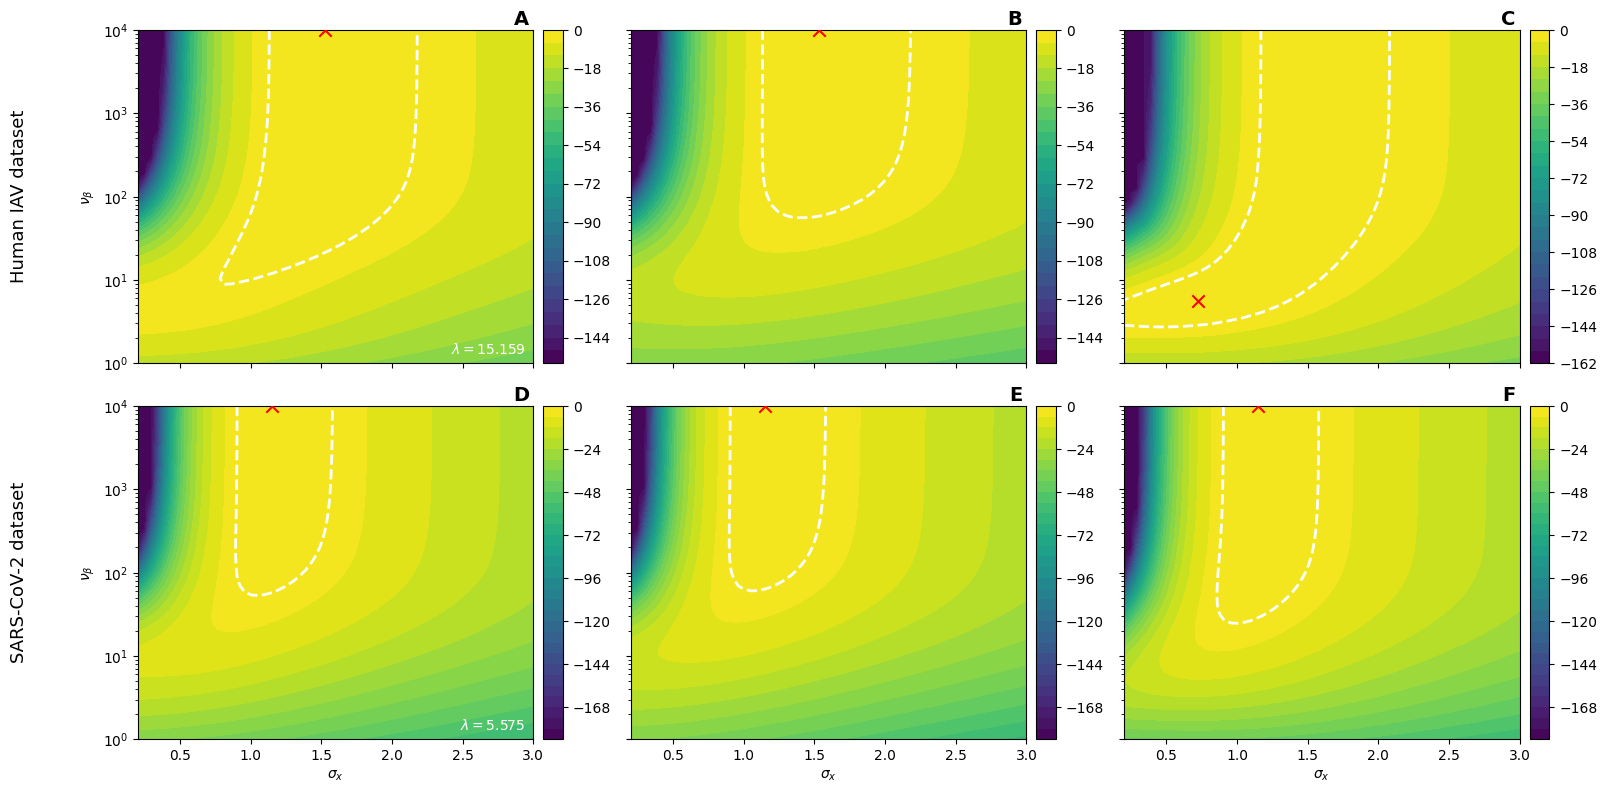

In [46]:
col_labels = ["fitexp", "flat", "no measurement noise"]
row_labels = ["Human IAV dataset", "SARS-CoV-2 dataset"]

# datasets_heatmap[row][col] -> row = dataset, col = model variant
datasets_heatmap = [
    [(mccrone_logL_fitexp,    sigma_grid_std, F2_mcc),
     (mccrone_logL_flat,      sigma_grid_std, None),
     (mccrone_logL_nom1,      sigma_grid_std, None)],
    [(tonkinhill_logL_fitexp, sigma_grid_std, F2_ton),
     (tonkinhill_logL_flat,   sigma_grid_std, None),
     (tonkinhill_logL_nom1,   sigma_grid_std, None)],
]

LOGL_FLOOR = -160
NROWS, NCOLS = 2, 3

# ---------------- plot ----------------
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, 8))

for row in range(NROWS):
    for col in range(NCOLS):
        ax = axes[row, col]

        panel_label = chr(ord("A") + row * NCOLS + col)
        ax.text(0.99, 1.06, panel_label, transform=ax.transAxes,
                ha="right", va="top", fontsize=14, fontweight="bold",
                color="black")

        logL_raw, sig_grid, F2 = datasets_heatmap[row][col]
        logL = np.copy(logL_raw)
        logL[logL < LOGL_FLOOR] = LOGL_FLOOR
        logL_centered = logL - np.max(logL)

        max_idx   = np.unravel_index(np.argmax(logL), logL.shape)
        sigma_hat = sig_grid[max_idx[0]]
        nu_hat    = nu_grid[max_idx[1]]

        cs = ax.contourf(sig_grid, nu_grid, logL_centered.T,
                         levels=30, cmap="viridis")
        if not np.all(logL_centered == 0):
            ax.contour(sig_grid, nu_grid, logL_centered.T,
                       levels=[threshold_95], colors="white",
                       linestyles="dashed", linewidths=2)

        ax.scatter(sigma_hat, nu_hat, color="red", marker="x", s=80, zorder=10,
                   label=fr"MLE: $\sigma$={sigma_hat:.2f}, $\nu$={nu_hat:.1f}")

        if F2 is not None:
            ax.text(0.98, 0.02, fr"$\lambda={1/F2:.3f}$", color="white",
                    fontsize=10, ha="right", va="bottom", transform=ax.transAxes)

        ax.set_yscale("log")
        ax.set_xlim(sig_grid[0], sig_grid[-1])
        ax.set_ylim(nu_grid[0], nu_grid[-1])

        # column titles on the top row only
        # if row == 0: ax.set_title(col_labels[col], fontsize=13)

        # x labels on the bottom row only
        if row == NROWS - 1:
            ax.set_xlabel(r"$\sigma_x$")
        else:
            ax.set_xticklabels([])

        # y labels on the first column only
        if col == 0:
            ax.set_ylabel(r"$\nu_{\beta}$")
            # dataset name as a rotated row label to the left
            ax.text(-0.30, 0.5, row_labels[row], transform=ax.transAxes,
                    rotation=90, ha="center", va="center", fontsize=13)
        else:
            ax.set_yticklabels([])

        cax  = make_axes_locatable(ax).append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(cs, cax=cax)
        # cbar.set_label("Log-likelihood")

plt.tight_layout()
plt.show()

#### Figure S6

In [48]:
LOD = 0.02
def logit_transform(f, eps=1e-12):
    f = np.clip(f, eps, 1 - eps)
    return np.log(f / (1.0 - f))


def bm_loglik_sigma_x_censored_varyingT_freqspace(
    X0, XT, T_arr, sigma_x,
    f_lower=0.02, f_upper=0.98,
    x_lower=None, x_upper=None,
):
    """
    Frequency-space likelihood for Brownian motion in X = logit(f),
    with interval censoring at BOTH ends of the frequency scale.

        fT <  f_lower  ->  log P(X_T <  x_lower | X_0)
        fT >  f_upper  ->  log P(X_T >  x_upper | X_0)
        otherwise      ->  log p_X(X_T | X_0) + log |dX/df_T|

    Set f_upper=None to disable upper censoring.
    """
    X0 = np.asarray(X0, float)
    XT = np.asarray(XT, float)
    T_arr = np.asarray(T_arr, float)

    if not (len(X0) == len(XT) == len(T_arr)):
        raise ValueError("X0, XT, T_arr must have the same length.")
    if np.any(T_arr <= 0):
        raise ValueError("All T must be > 0.")
    if sigma_x <= 0:
        raise ValueError("sigma_x must be positive.")

    if x_lower is None:
        x_lower = float(logit_transform(f_lower))
    if x_upper is None and f_upper is not None:
        x_upper = float(logit_transform(f_upper))
    if x_upper is not None and x_upper <= x_lower:
        raise ValueError("upper threshold must exceed lower threshold.")

    sd = sigma_x * np.sqrt(T_arr)

    # strict comparisons on both ends, matching the spectral implementation
    is_lower = XT < x_lower
    is_upper = (np.zeros_like(is_lower) if x_upper is None
                else XT > x_upper)
    is_exact = ~(is_lower | is_upper)

    ll = 0.0

    if np.any(is_exact):
        z = (XT[is_exact] - X0[is_exact]) / sd[is_exact]
        log_density_X = (-0.5 * z**2
                         - np.log(sd[is_exact])
                         - 0.5 * np.log(2 * np.pi))
        fT_e = np.clip(1.0 / (1.0 + np.exp(-XT[is_exact])), 1e-12, 1 - 1e-12)
        log_jacobian = -np.log(fT_e) - np.log1p(-fT_e)
        ll += np.sum(log_density_X + log_jacobian)

    if np.any(is_lower):
        ll += np.sum(log_ndtr((x_lower - X0[is_lower]) / sd[is_lower]))

    if np.any(is_upper):
        ll += np.sum(log_ndtr((X0[is_upper] - x_upper) / sd[is_upper]))

    return float(ll)

def compute_sigma_profile(df2, sigma_grid, f_lower=0.02, f_upper=0.98):
    chi2_95_df1 = 3.841458820694124
    cut = -0.5 * chi2_95_df1

    ll_grid = np.array([
        bm_loglik_sigma_x_censored_varyingT_freqspace(
            X0=df2["X0"].to_numpy(),
            XT=df2["XT"].to_numpy(),
            T_arr=df2["T"].to_numpy(),
            sigma_x=s,
            f_lower=f_lower,
            f_upper=f_upper,
        )
        for s in sigma_grid
    ], dtype=float)

    mle_idx = int(np.argmax(ll_grid))
    sigma_mle = float(sigma_grid[mle_idx])
    ll_mle = float(ll_grid[mle_idx])
    ll_centered = ll_grid - ll_mle

    i_hat = mle_idx

    # left CI
    left_idx_candidates = np.where(ll_centered[:i_hat + 1] < cut)[0]
    if len(left_idx_candidates) == 0:
        ci_low = float(sigma_grid[0])
    else:
        i1 = int(left_idx_candidates[-1])
        i2 = min(i1 + 1, i_hat)
        x1, x2 = float(sigma_grid[i1]), float(sigma_grid[i2])
        y1, y2 = float(ll_centered[i1]), float(ll_centered[i2])
        ci_low = x1 + (cut - y1) * (x2 - x1) / (y2 - y1) if y2 != y1 else x1

    # right CI
    right_idx_candidates = np.where(ll_centered[i_hat:] < cut)[0]
    if len(right_idx_candidates) == 0:
        ci_high = float(sigma_grid[-1])
    else:
        j2 = int(i_hat + right_idx_candidates[0])
        j1 = max(j2 - 1, i_hat)
        x1, x2 = float(sigma_grid[j1]), float(sigma_grid[j2])
        y1, y2 = float(ll_centered[j1]), float(ll_centered[j2])
        ci_high = x1 + (cut - y1) * (x2 - x1) / (y2 - y1) if y2 != y1 else x2

    return {
        "ll_grid": ll_grid,
        "ll_centered": ll_centered,
        "sigma_mle": sigma_mle,
        "ll_mle": ll_mle,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "cut": cut,
    }

label_font = 13
tick_font = 11
panel_font = 13


def plot_segments(ax, df2, panel_label, xlabel="Days post symptom onset"):
    id_col = "Individual ID" if "Individual ID" in df2.columns else (
        "Individual" if "Individual" in df2.columns else None
    )

    if id_col is None:
        for _, row in df2.iterrows():
            ax.plot(
                [row["DPS1"], row["DPS2"]],
                [row["DPS1 Frequency"], row["DPS2 Frequency"]],
                alpha=0.7
            )
    else:
        for _, group in df2.groupby(id_col):
            for _, row in group.iterrows():
                ax.plot(
                    [row["DPS1"], row["DPS2"]],
                    [row["DPS1 Frequency"], row["DPS2 Frequency"]],
                    alpha=0.7
                )

    ax.set_xlabel(xlabel, fontsize=label_font)
    ax.axhline(LOD, linestyle=":", label="LOD", color="grey")
    ax.set_ylabel("iSNV frequency ($f_2$)", fontsize=label_font)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", labelsize=tick_font)

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )


def plot_ll_panel(ax, sigma_grid, prof, panel_label):
    ax.plot(sigma_grid, prof["ll_grid"])
    ax.axvline(
        prof["sigma_mle"],
        linestyle="--",
        label=rf"MLE $\hat{{\sigma}}_x$ = {prof['sigma_mle']:.3f}"
    )
    # ax.scatter([prof["sigma_mle"]], [0.0], zorder=3)
    # ax.axhline(prof["cut"], color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.axvspan(prof["ci_low"], prof["ci_high"], alpha=0.15)
    ax.axvline(
        prof["ci_low"],
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label=rf"95% CI = [{prof['ci_low']:.3f}, {prof['ci_high']:.3f}]"
    )
    ax.axvline(prof["ci_high"], color="gray", linestyle="--", linewidth=1.5)

    ax.set_xlabel(r"$\sigma_x$", fontsize=label_font)
    ax.set_ylabel("Log-likelihood", fontsize=label_font)
    ax.tick_params(axis="both", labelsize=tick_font)

    # ax.legend(frameon=False, fontsize=8, loc="lower right")

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )


def plot_heatmap_panel(ax, fig, targets, panel_label,
                       eps_min=0.0, eps_max=5.0, n_eps=400,
                       rho_min=0.0, rho_max=1.0, n_rho=400):
    epsilon = np.linspace(eps_min, eps_max, n_eps)
    rho = np.linspace(rho_min, rho_max, n_rho)
    E, R = np.meshgrid(epsilon, rho)
    sigma = E * np.sqrt(2 * (1 - R))

    im = ax.imshow(
        sigma,
        origin="lower",
        aspect="auto",
        extent=[eps_min, eps_max, rho_min, rho_max]
    )

    cs = ax.contour(
        E, R, sigma,
        levels=sorted(targets),
        linewidths=2,
        colors="white",
        linestyles=["dashed", "solid", "dashed"]
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\sigma_x$', fontsize=label_font)
    cbar.ax.tick_params(labelsize=tick_font)

    ax.set_xlabel(r'$\epsilon$', fontsize=label_font)
    ax.set_ylabel(r'$\rho$', fontsize=label_font)
    ax.tick_params(axis="both", labelsize=tick_font)

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )

In [49]:
vaninsberghe = pd.read_csv("data/raw_data/table_S3.csv")
filtered_vaninsberghe = vaninsberghe[vaninsberghe["Subset"] == 1]
vani = filtered_vaninsberghe.copy()
vani["T"] = vani["DPS2"] - vani["DPS1"]

# Build X-space pairs from frequencies
vani["X0"] = vani["DPS1 Frequency"].map(logit_transform)
vani["XT"] = vani["DPS2 Frequency"].map(logit_transform)

# Example: compute total loglik at a chosen sigma_x
sigma_x = 0.2
total_ll = bm_loglik_sigma_x_censored_varyingT_freqspace(
    X0=vani["X0"].to_numpy(),
    XT=vani["XT"].to_numpy(),
    T_arr=vani["T"].to_numpy(),
    sigma_x=sigma_x,
    f_lower=0.02,
    f_upper=0.98
)
print("Total loglik:", total_ll)


Total loglik: -3531.156772377826


In [50]:
# ============================================================
# 1) Paired dataset preprocessing
# ============================================================

def preprocess_paired_frequency_dataset(
    df,
    mode,
    lod=0.02,
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
):
    """
    mode:
        - "drop_zero": drop rows where f2 == 0
        - "floor_below_lod": replace f2 < lod with lod
        - "replace_zero_only": replace only f2 == 0 with lod
    """
    out = df.copy()

    out[f1_col] = pd.to_numeric(out[f1_col], errors="coerce")
    out[f2_col] = pd.to_numeric(out[f2_col], errors="coerce")
    out[dps1_col] = pd.to_numeric(out[dps1_col], errors="coerce")
    out[dps2_col] = pd.to_numeric(out[dps2_col], errors="coerce")

    out = out.dropna(subset=[dps1_col, dps2_col, f1_col, f2_col]).copy()

    if mode == "drop_zero":
        out = out[out[f2_col] != 0].copy()

    elif mode == "floor_below_lod":
        # lower bound
        out.loc[out[f2_col] < lod, f2_col] = lod
        
        # upper bound
        out.loc[out[f2_col] > (1 - lod), f2_col] = (1 - lod)

    elif mode == "replace_zero_only":
        out.loc[out[f2_col] == 0, f2_col] = lod

    else:
        raise ValueError(
            "mode must be one of: "
            "'drop_zero', 'floor_below_lod', 'replace_zero_only'"
        )

    return out


# ============================================================
# 2) Convert paired frequency dataset to common analysis format
# ============================================================

def prepare_paired_frequency_dataset(
    df,
    logit_transform,
    dataset_name="Dataset",
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
):
    """
    Build common-format dataframe with columns:
        T, X1, X2, abs_dX, dataset
    """
    out = df.copy()

    out["T"] = out[dps2_col].astype(float) - out[dps1_col].astype(float)
    out["f1"] = out[f1_col].astype(float)
    out["f2"] = out[f2_col].astype(float)

    out["X1"] = logit_transform(out["f1"].values)
    out["X2"] = logit_transform(out["f2"].values)
    out["abs_dX"] = np.abs(out["X2"] - out["X1"])
    out["dataset"] = dataset_name

    return out[["T", "X1", "X2", "abs_dX", "dataset"]].copy()


# ============================================================
# 3) Filtering helpers
# ============================================================

def filter_timepoints_with_min_n(df_common, min_n=2):
    """
    Keep only T values with at least min_n observations.
    """
    counts = df_common.groupby("T").size()
    keep_T = counts[counts >= min_n].index
    return df_common[df_common["T"].isin(keep_T)].copy()


def exclude_specific_timepoints(df_common, exclude_T=None):
    """
    Remove specified T values.
    """
    if exclude_T is None:
        return df_common.copy()
    return df_common[~df_common["T"].isin(exclude_T)].copy()


# ============================================================
# 4) Summary helper
# ============================================================

def summarize_dataset(df_common):
    summary = (
        df_common.groupby("T", as_index=False)
        .agg(
            X_mean=("X2", "mean"),
            abs_dX_mean=("abs_dX", "mean"),
            n=("abs_dX", "size"),
            abs_dX_std=("abs_dX", "std"),
        )
        .sort_values("T")
    )

    summary["abs_dX_sem"] = summary["abs_dX_std"] / np.sqrt(summary["n"])
    return summary


def prepend_zero_for_curve(T_vals, y_vals):
    """
    Prepend (0,0) so a curve starts at zero.
    """
    T_vals = np.asarray(T_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)

    if len(T_vals) == 0:
        return np.array([0.0]), np.array([0.0])

    if T_vals[0] != 0:
        T_vals = np.insert(T_vals, 0, 0.0)
        y_vals = np.insert(y_vals, 0, 0.0)
    else:
        y_vals[0] = 0.0

    return T_vals, y_vals





In [51]:
# vaninsberghe
sigma_grid = np.linspace(0.2, 5, 60)
nu_grid    = np.logspace(0, 4, 60)

d = np.load("heatmap_results/vaninsberghe_logL_fitexp.npz")
vaninsberghe_logL_fitexp, F2_vani = d["logL"], float(d["f2_mean"])

vaninsberghe_logL_flat = np.load("heatmap_results/vaninsberghe_logL_flat.npy")
vaninsberghe_logL_nom1 = np.load("heatmap_results/vaninsberghe_logL_nom1.npy")


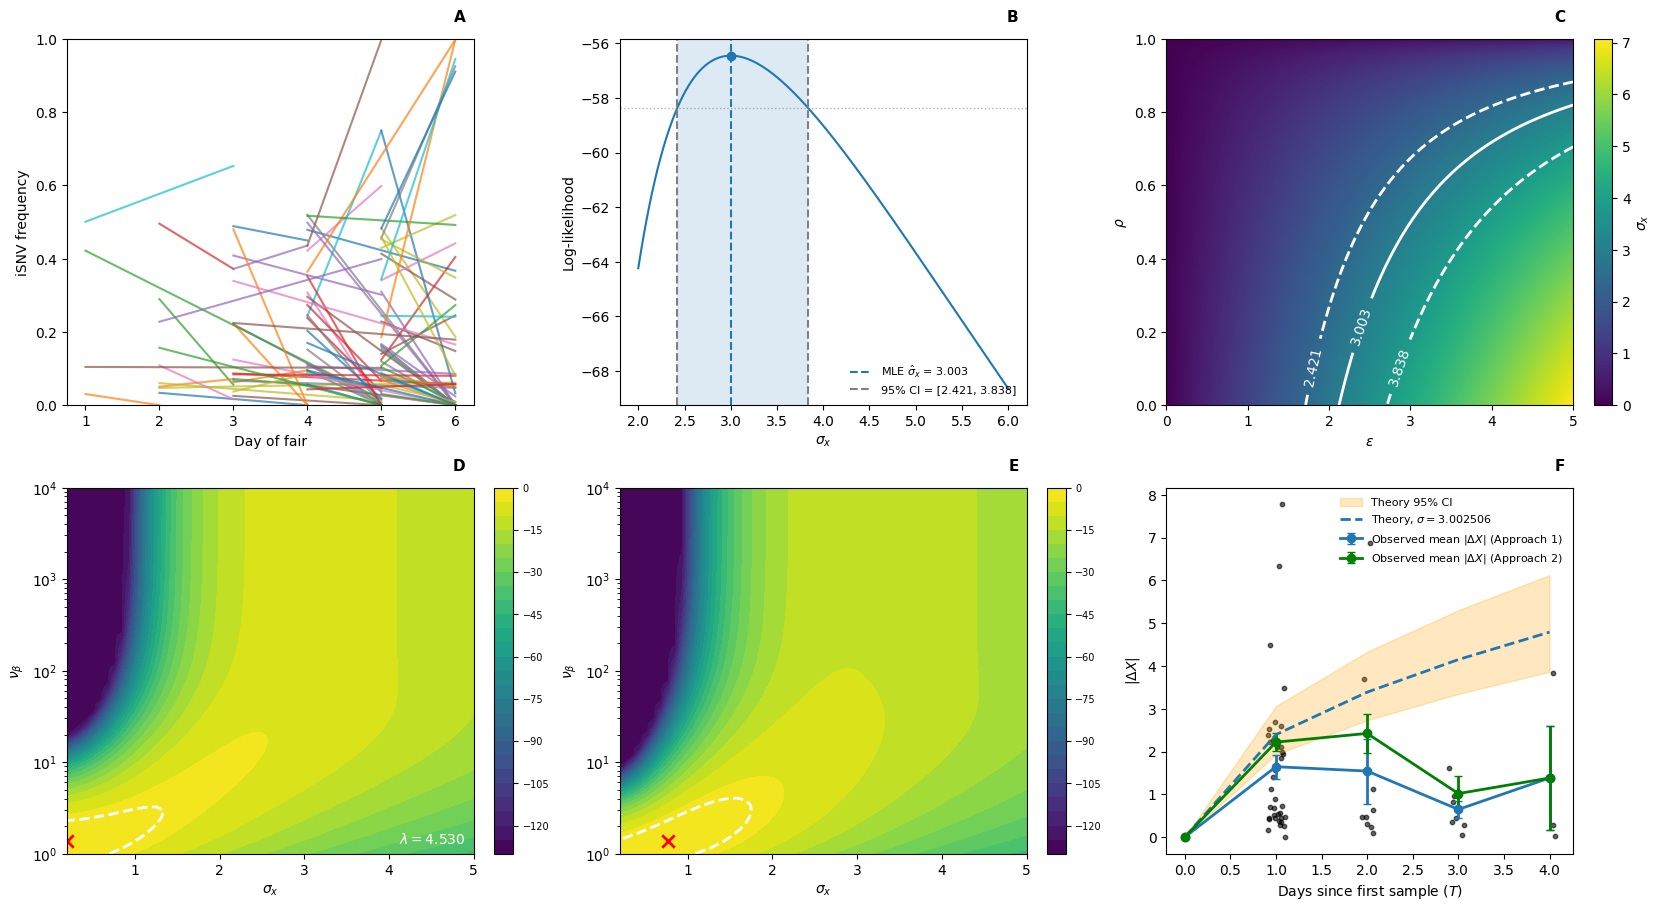

MLE sigma_x        = 3.002506
Max log-likelihood = -56.452185
95% LR CI          = [2.421006, 3.837987]
F2_vani (fitexp)   = 0.220735
 fitexp: sigma_x = 0.2, nu = 1.366, logL = -49.3938
   nom1: sigma_x = 0.7695, nu = 1.366, logL = -45.8134


In [52]:
# ============================================================
# 2 x 3 summary figure
#
#   Row 1:  A  DPS segments
#           B  Profile log-likelihood over sigma_x
#           C  sigma_x heatmap over (epsilon, rho), contours = B's MLE/CI
#   Row 2:  D  logL(sigma_x, nu) heatmap, fitted exponential prior
#           E  logL(sigma_x, nu) heatmap, nominal (nu = 1) prior
#           F  |dX| vs T (drop_zero vs floor)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2


# ============================================================
# Config
# ============================================================

LOGL_FLOOR = -126     # clipping floor for the row-2 heatmaps

CHI2_95_DF1 = 3.841458820694124
CUT = -0.5 * CHI2_95_DF1


# ============================================================
# Build Vani datasets for Panel F
# ============================================================

vani_drop_zero = preprocess_paired_frequency_dataset(
    df=vani,
    mode="drop_zero",
    lod=0.005,
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

vani_floor = preprocess_paired_frequency_dataset(
    df=vani,
    mode="floor_below_lod",
    lod=0.005,
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

df_vani_drop_zero_common = prepare_paired_frequency_dataset(
    df=vani_drop_zero,
    logit_transform=logit_transform,
    dataset_name="Vani",
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

df_vani_floor_common = prepare_paired_frequency_dataset(
    df=vani_floor,
    logit_transform=logit_transform,
    dataset_name="Vani",
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

df_vani_drop_zero_common = filter_timepoints_with_min_n(
    df_vani_drop_zero_common,
    min_n=2,
)

df_vani_floor_common = filter_timepoints_with_min_n(
    df_vani_floor_common,
    min_n=2,
)


# ============================================================
# Load the (sigma_x, nu) log-likelihood grids for row 2
# ============================================================

sigma_grid_hm = np.linspace(0.2, 5, 60)
nu_grid_hm = np.logspace(0, 4, 60)

_d = np.load("heatmap_results/vaninsberghe_logL_fitexp.npz")
vaninsberghe_logL_fitexp = _d["logL"]
F2_vani = float(_d["f2_mean"])

vaninsberghe_logL_nom1 = np.load("heatmap_results/vaninsberghe_logL_nom1.npy")


# ============================================================
# Helpers
# ============================================================

def add_panel_letter(ax, letter, x=0.98, y=1.08):
    ax.text(
        x, y, letter,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=11,
    )


def profile_ci_from_grid(param_grid, ll_grid, cut=CUT):
    """Linear-interpolated likelihood-ratio CI from a 1-D profile."""
    param_grid = np.asarray(param_grid, dtype=float)
    ll_grid = np.asarray(ll_grid, dtype=float)

    i_hat = int(np.argmax(ll_grid))
    ll_centered = ll_grid - ll_grid[i_hat]

    left = np.where(ll_centered[:i_hat + 1] < cut)[0]
    if len(left) == 0:
        lo = float(param_grid[0])
    else:
        i1 = int(left[-1])
        i2 = min(i1 + 1, i_hat)
        x1, x2 = float(param_grid[i1]), float(param_grid[i2])
        y1, y2 = float(ll_centered[i1]), float(ll_centered[i2])
        lo = x1 + (cut - y1) * (x2 - x1) / (y2 - y1) if y2 != y1 else x1

    right = np.where(ll_centered[i_hat:] < cut)[0]
    if len(right) == 0:
        hi = float(param_grid[-1])
    else:
        j2 = int(i_hat + right[0])
        j1 = max(j2 - 1, i_hat)
        x1, x2 = float(param_grid[j1]), float(param_grid[j2])
        y1, y2 = float(ll_centered[j1]), float(ll_centered[j2])
        hi = x1 + (cut - y1) * (x2 - x1) / (y2 - y1) if y2 != y1 else x2

    return float(param_grid[i_hat]), lo, hi, ll_centered


def plot_abs_dx_panel(
    ax,
    df_blue,
    df_green,
    sigma,
    sigma_ci,
    xlabel,
    panel_letter,
    blue_label,
    green_label,
    line_color="C0",
):
    df_blue = (
        df_blue
        .dropna(subset=["T", "X1", "X2", "abs_dX"])
        .copy()
        .sort_values("T")
    )

    summary_blue = summarize_dataset(df_blue)

    rng = np.random.default_rng(seed=42)
    jitter = rng.uniform(-0.1, 0.1, size=len(df_blue))

    ax.scatter(
        df_blue["T"] + jitter,
        df_blue["abs_dX"],
        alpha=0.6,
        s=10,
        color="black",
    )

    T_blue = summary_blue["T"].to_numpy(dtype=float)
    y_blue = summary_blue["abs_dX_mean"].to_numpy(dtype=float)
    sem_blue = summary_blue["abs_dX_sem"].to_numpy(dtype=float)

    T_blue_plot, y_blue_plot = prepend_zero_for_curve(T_blue, y_blue)

    if len(T_blue_plot) == len(sem_blue) + 1:
        sem_blue_plot = np.insert(sem_blue, 0, 0.0)
    else:
        sem_blue_plot = sem_blue.copy()
        if len(sem_blue_plot) > 0:
            sem_blue_plot[0] = 0.0

    ax.errorbar(
        T_blue_plot,
        y_blue_plot,
        yerr=sem_blue_plot,
        fmt="o-",
        linewidth=2,
        capsize=3,
        color=line_color,
        label=blue_label,
    )

    if df_green is not None:
        df_green = (
            df_green
            .dropna(subset=["T", "X1", "X2", "abs_dX"])
            .copy()
            .sort_values("T")
        )

        summary_green = summarize_dataset(df_green)

        T_green = summary_green["T"].to_numpy(dtype=float)
        y_green = summary_green["abs_dX_mean"].to_numpy(dtype=float)
        sem_green = summary_green["abs_dX_sem"].to_numpy(dtype=float)

        T_green_plot, y_green_plot = prepend_zero_for_curve(T_green, y_green)

        if len(T_green_plot) == len(sem_green) + 1:
            sem_green_plot = np.insert(sem_green, 0, 0.0)
        else:
            sem_green_plot = sem_green.copy()
            if len(sem_green_plot) > 0:
                sem_green_plot[0] = 0.0

        ax.errorbar(
            T_green_plot,
            y_green_plot,
            yerr=sem_green_plot,
            fmt="o-",
            linewidth=2,
            capsize=3,
            color="green",
            label=green_label,
        )

    if sigma is not None:
        t_candidates = [0.0]
        t_candidates.extend(summary_blue["T"].tolist())

        if df_green is not None and len(df_green) > 0:
            t_candidates.extend(summary_green["T"].tolist())

        T_theory = np.array(sorted(set(float(t) for t in t_candidates)))

        theory = sigma * np.sqrt(T_theory) * np.sqrt(2.0 / np.pi)

        if sigma_ci is not None:
            sigma_lo, sigma_hi = sigma_ci

            theory_lo = sigma_lo * np.sqrt(T_theory) * np.sqrt(2.0 / np.pi)
            theory_hi = sigma_hi * np.sqrt(T_theory) * np.sqrt(2.0 / np.pi)

            ax.fill_between(
                T_theory,
                theory_lo,
                theory_hi,
                color="orange",
                alpha=0.25,
                label="Theory 95% CI",
            )

        ax.plot(
            T_theory,
            theory,
            "--",
            linewidth=2,
            label=rf"Theory, $\sigma={sigma:.6f}$",
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$|\Delta X|$")
    ax.legend(frameon=False, fontsize=8)

    add_panel_letter(ax, panel_letter)


def plot_logL_heatmap(
    fig,
    ax,
    logL_grid,
    sigma_grid,
    nu_grid,
    panel_letter,
    title,
    floor=LOGL_FLOOR,
):
    max_idx = np.unravel_index(np.argmax(logL_grid), logL_grid.shape)

    sigma_hat = float(sigma_grid[max_idx[0]])
    nu_hat = float(nu_grid[max_idx[1]])
    max_logL = float(logL_grid[max_idx])

    logL_centered = logL_grid - max_logL
    logL_plot = np.maximum(logL_centered, floor)

    lr_cutoff = -0.5 * chi2.ppf(0.95, df=2)

    cs = ax.contourf(sigma_grid, nu_grid, logL_plot.T, levels=30)

    ax.contour(
        sigma_grid,
        nu_grid,
        logL_centered.T,
        levels=[lr_cutoff],
        colors="white",
        linewidths=2,
    )

    ax.scatter(
        sigma_hat,
        nu_hat,
        color="red",
        marker="x",
        s=80,
        linewidths=2,
    )

    ax.set_yscale("log")
    ax.set_xlabel(r"$\sigma_x$")
    ax.set_ylabel(r"$\nu_{\beta}$")
    # ax.set_title(title, fontsize=10)

    cbar = fig.colorbar(cs, ax=ax, fraction=0.046, pad=0.04)
    #cbar.set_label("Centered log-likelihood", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    add_panel_letter(ax, panel_letter)

    return sigma_hat, nu_hat, max_logL


# ============================================================
# Create 2 x 3 figure
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16.5, 9.0),
    constrained_layout=True,
)

(ax_a, ax_b, ax_c), (ax_d, ax_e, ax_f) = axes


# -----------------------
# Panel A: DPS segments
# -----------------------

id_col = (
    "Individual ID"
    if "Individual ID" in vani.columns
    else ("Individual" if "Individual" in vani.columns else None)
)

if id_col is None:
    for _, row in vani.iterrows():
        ax_a.plot(
            [row["DPS1"], row["DPS2"]],
            [row["DPS1 Frequency"], row["DPS2 Frequency"]],
            alpha=0.7,
        )
else:
    for _, group in vani.groupby(id_col):
        for _, row in group.iterrows():
            ax_a.plot(
                [row["DPS1"], row["DPS2"]],
                [row["DPS1 Frequency"], row["DPS2 Frequency"]],
                alpha=0.7,
            )

ax_a.set_xlabel("Day of fair")
ax_a.set_ylabel("iSNV frequency")
ax_a.set_ylim(0, 1)

add_panel_letter(ax_a, "A")


# -----------------------------------------
# Panel B: profile log-likelihood over sigma_x
# -----------------------------------------

sigma_grid = np.linspace(2, 6, 400)

ll_grid = np.array([
    bm_loglik_sigma_x_censored_varyingT_freqspace(
        X0=vani["X0"].to_numpy(),
        XT=vani["XT"].to_numpy(),
        T_arr=vani["T"].to_numpy(),
        sigma_x=s,
        f_lower=0.02,
        f_upper=0.98,
    )
    for s in sigma_grid
], dtype=float)

sigma_mle, ci_low, ci_high, _ = profile_ci_from_grid(sigma_grid, ll_grid)
ll_mle = float(np.max(ll_grid))

# Plotted on the raw log-likelihood scale (not centered at the maximum).
# The CI is still defined by the LR cutoff, now drawn at ll_mle + CUT.
ax_b.plot(sigma_grid, ll_grid)

ax_b.axvline(
    sigma_mle,
    linestyle="--",
    label=rf"MLE $\hat{{\sigma}}_x$ = {sigma_mle:.3f}",
)

ax_b.scatter([sigma_mle], [ll_mle], zorder=3)

ax_b.axhline(ll_mle + CUT, color="gray", linestyle=":", linewidth=1, alpha=0.6)

ax_b.axvspan(ci_low, ci_high, alpha=0.15)

ax_b.axvline(
    ci_low,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=rf"95% CI = [{ci_low:.3f}, {ci_high:.3f}]",
)

ax_b.axvline(ci_high, color="gray", linestyle="--", linewidth=1.5)

ax_b.set_xlabel(r"$\sigma_x$")
ax_b.set_ylabel("Log-likelihood")
ax_b.legend(frameon=False, fontsize=8, loc="lower right")

add_panel_letter(ax_b, "B")


# -----------------------------------------
# Panel C: sigma_x over (epsilon, rho)
# Contours are taken directly from Panel B
# -----------------------------------------

eps_min, eps_max, n_eps = 0.0, 5.0, 400
rho_min, rho_max, n_rho = 0.0, 1.0, 400

epsilon = np.linspace(eps_min, eps_max, n_eps)
rho = np.linspace(rho_min, rho_max, n_rho)

E, R = np.meshgrid(epsilon, rho)

sigma_heatmap = E * np.sqrt(2 * (1 - R))

targets = sorted([ci_low, sigma_mle, ci_high])
styles = ["dashed", "solid", "dashed"]

im = ax_c.imshow(
    sigma_heatmap,
    origin="lower",
    aspect="auto",
    extent=[eps_min, eps_max, rho_min, rho_max],
)

cbar_c = fig.colorbar(im, ax=ax_c, fraction=0.046, pad=0.04)
cbar_c.set_label(r"$\sigma_x$")

cs_c = ax_c.contour(
    E,
    R,
    sigma_heatmap,
    levels=targets,
    linewidths=2,
    colors="white",
    linestyles=styles,
)

ax_c.clabel(
    cs_c,
    inline=True,
    fontsize=10,
    fmt={t: f"{t:.3f}" for t in targets},
    colors="white",
)

ax_c.set_xlabel(r"$\epsilon$")
ax_c.set_ylabel(r"$\rho$")

add_panel_letter(ax_c, "C")


# -----------------------------------------
# Panels D / E: joint (sigma_x, nu) log-likelihood
# -----------------------------------------

hm_d = plot_logL_heatmap(
    fig, ax_d, vaninsberghe_logL_fitexp,
    sigma_grid_hm, nu_grid_hm,
    panel_letter="D",
    title="Fitted exponential prior",
)
ax_d.text(
    0.98, 0.02, fr"$\lambda={1/F2_vani:.3f}$",
    color="white", fontsize=10, ha="right", va="bottom",
    transform=ax_d.transAxes,
)

hm_e = plot_logL_heatmap(
    fig, ax_e, vaninsberghe_logL_nom1,
    sigma_grid_hm, nu_grid_hm,
    panel_letter="E",
    title=r"Nominal prior ($\nu = 1$)",
)


# -----------------------------------------
# Panel F: |dX| vs T
# -----------------------------------------

plot_abs_dx_panel(
    ax=ax_f,
    df_blue=df_vani_drop_zero_common.copy(),
    df_green=df_vani_floor_common.copy(),
    sigma=3.002506,
    sigma_ci=(2.421006, 3.837987),
    xlabel=r"Days since first sample ($T$)",
    panel_letter="F",
    blue_label=r"Observed mean $|\Delta X|$ (Approach 1)",
    green_label=r"Observed mean $|\Delta X|$ (Approach 2)",
    line_color="C0",
)


plt.show()


# ============================================================
# Console summary
# ============================================================

print(f"MLE sigma_x        = {sigma_mle:.6f}")
print(f"Max log-likelihood = {ll_mle:.6f}")
print(f"95% LR CI          = [{ci_low:.6f}, {ci_high:.6f}]")
print(f"F2_vani (fitexp)   = {F2_vani:.6f}")

for name, (s_hat, n_hat, m_ll) in zip(
    ["fitexp", "nom1"], [hm_d, hm_e]
):
    print(f"{name:>7s}: sigma_x = {s_hat:.4g}, nu = {n_hat:.4g}, logL = {m_ll:.4f}")

#### Figure S7

In [5]:

# ============================================================
# KS test of ΔX against normal distribution
# Model:
#   ΔX ~ Normal(0, sigma_x^2 T)
# ============================================================

sigma_x = 1.5   # simulated sigma_x

# Make sure dX exists
df_sim_common = df_sim_common.copy()
df_sim_common["dX"] = df_sim_common["X2"] - df_sim_common["X1"]

df_ks = df_sim_common.dropna(subset=["T", "dX"]).copy()
df_ks["T"] = df_ks["T"].astype(float)
df_ks["dX"] = df_ks["dX"].astype(float)

ks_results = []

for T_val, sub in df_ks.groupby("T"):
    x = sub["dX"].to_numpy(dtype=float)

    # Normal standard deviation for this time interval
    sd_T = sigma_x * np.sqrt(T_val)

    # One-sample KS test against Normal(0, sigma_x^2 T)
    ks_stat, p_value = stats.kstest(
        x,
        "norm",
        args=(0, sd_T)  # loc=0, scale=sigma_x*sqrt(T)
    )

    ks_results.append({
        "T": T_val,
        "n": len(x),
        "sigma_x": sigma_x,
        "expected_mean_dX": 0.0,
        "observed_mean_dX": np.mean(x),
        "expected_sd_dX": sd_T,
        "observed_sd_dX": np.std(x, ddof=1),
        "KS_statistic": ks_stat,
        "p_value": p_value
    })

ks_results_df = pd.DataFrame(ks_results).sort_values("T")
ks_results_df = ks_results_df[~ks_results_df["T"].isin([1, 2])].copy()

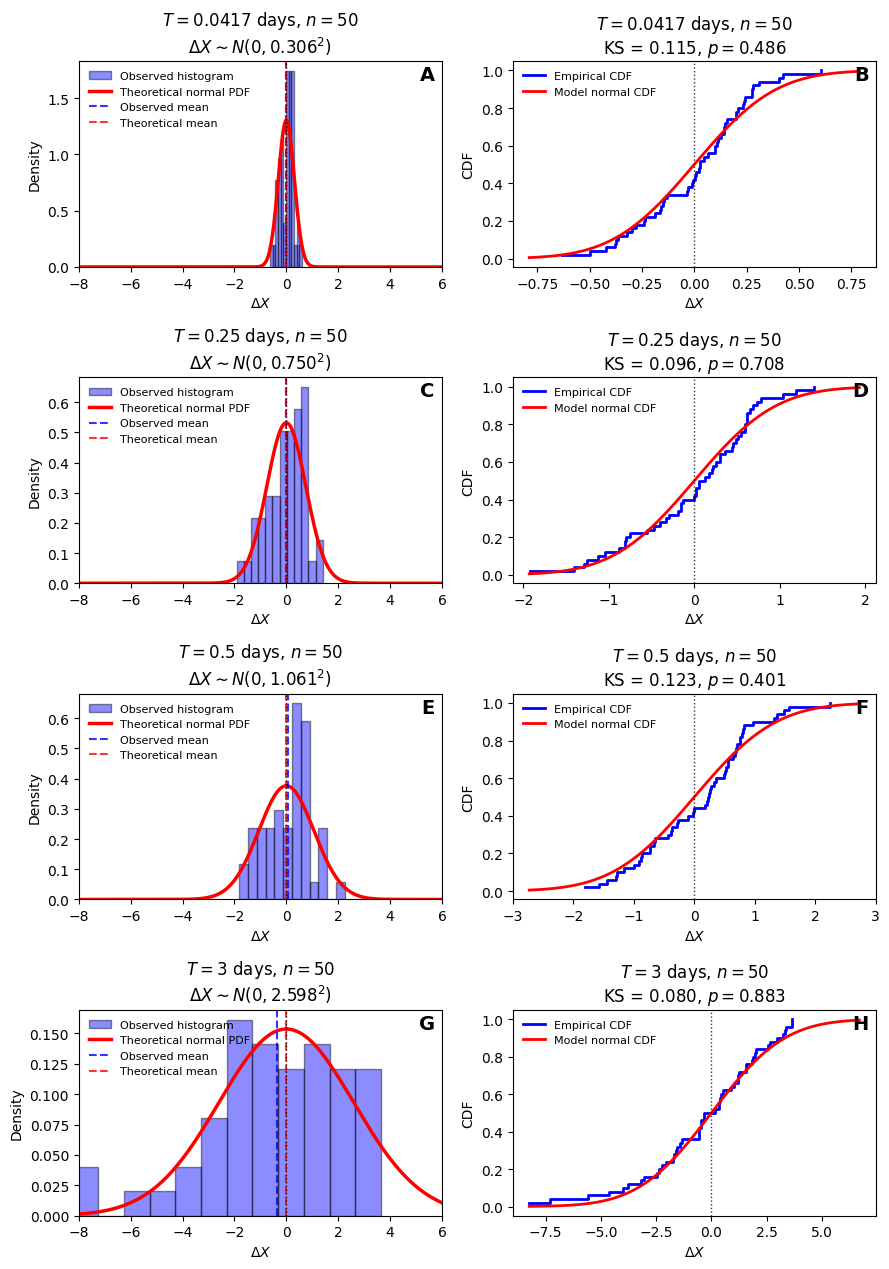

In [6]:
# ============================================================
# Stacked PDF + CDF figure
# Rows = different T values
# Col 1 = distribution/PDF
# Col 2 = CDF
# ============================================================
T_values = np.sort(ks_results_df["T"].unique())
n_rows = len(T_values)
n_cols = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(9, 3.2 * n_rows),
    sharex=False,
    sharey=False
)

# If only one T value, make axes consistently 2D
if n_rows == 1:
    axes = axes.reshape(1, 2)

panel_labels = list(string.ascii_uppercase)
label_i = 0

# Fixed x-range for distribution plots
x_dist_min = -8
x_dist_max = 6

for i, T_val in enumerate(T_values):
    sub = df_ks[df_ks["T"] == T_val]
    x_obs = sub["dX"].to_numpy(dtype=float)
    x_sorted = np.sort(x_obs)
    n = len(x_obs)

    sd_T = sigma_x * np.sqrt(T_val)

    # Use fixed x grid for distribution plot
    x_grid_dist = np.linspace(x_dist_min, x_dist_max, 500)

    # Use data-aware x grid for CDF plot
    x_min = min(x_obs.min(), stats.norm.ppf(0.005, loc=0, scale=sd_T))
    x_max = max(x_obs.max(), stats.norm.ppf(0.995, loc=0, scale=sd_T))
    x_grid_cdf = np.linspace(x_min, x_max, 500)

    row = ks_results_df[ks_results_df["T"] == T_val].iloc[0]
    ks_stat = row["KS_statistic"]
    p_value = row["p_value"]

    # --------------------------------------------------------
    # Column 1: histogram vs model PDF
    # --------------------------------------------------------
    ax = axes[i, 0]

    pdf_theory = stats.norm.pdf(x_grid_dist, loc=0, scale=sd_T)

    ax.hist(
        x_obs,
        bins=12,
        density=True,
        alpha=0.45,
        color="blue",
        edgecolor="black",
        label="Observed histogram"
    )

    ax.plot(
        x_grid_dist,
        pdf_theory,
        color="red",
        linewidth=2.5,
        label="Theoretical normal PDF"
    )

    observed_mean = np.mean(x_obs)
    theoretical_mean = 0.0

    ax.axvline(
        observed_mean,
        color="blue",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Observed mean"
    )

    ax.axvline(
        theoretical_mean,
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Theoretical mean"
    )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1,
        alpha=0.8
    )

    ax.set_xlim(x_dist_min, x_dist_max)

    ax.set_title(
        rf"$T = {T_val:.3g}$ days, $n = {n}$" "\n"
        rf"$\Delta X \sim N(0, {sd_T:.3f}^2)$"
    )

    ax.set_xlabel(r"$\Delta X$")
    ax.set_ylabel("Density")
    ax.legend(frameon=False, fontsize=8)

    ax.text(
        0.98,
        0.98,
        panel_labels[label_i],
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight="bold"
    )
    label_i += 1

    # --------------------------------------------------------
    # Column 2: empirical CDF vs model CDF
    # --------------------------------------------------------
    ax = axes[i, 1]

    ecdf = np.arange(1, n + 1) / n
    model_cdf = stats.norm.cdf(x_grid_cdf, loc=0, scale=sd_T)

    ax.step(
        x_sorted,
        ecdf,
        where="post",
        color="blue",
        linewidth=2,
        label="Empirical CDF"
    )

    ax.plot(
        x_grid_cdf,
        model_cdf,
        color="red",
        linewidth=2,
        label="Model normal CDF"
    )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1,
        alpha=0.8
    )

    ax.set_title(
        rf"$T = {T_val:.3g}$ days, $n = {n}$" "\n"
        rf"KS = {ks_stat:.3f}, $p = {p_value:.3g}$"
    )

    ax.set_xlabel(r"$\Delta X$")
    ax.set_ylabel("CDF")
    ax.legend(frameon=False, fontsize=8)

    ax.text(
        0.98,
        0.98,
        panel_labels[label_i],
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight="bold"
    )
    label_i += 1

plt.tight_layout()
plt.show()

#### Figure S8

In [7]:
# ============================================================
# McCrone parameters
# ============================================================

sigma_mle = 1.52
sigma_ci_low = 1.194979
sigma_ci_high = 2.015377

# ============================================================
# Prepare McCrone data
# ============================================================

df_plot = df_mccrone_drop_zero_common.copy()
df_plot["dX"] = df_plot["X2"] - df_plot["X1"]

df_plot = df_plot.dropna(subset=["T", "dX"]).copy()
df_plot["T"] = df_plot["T"].astype(float)
df_plot["dX"] = df_plot["dX"].astype(float)

T_values = np.sort(df_plot["T"].unique())

# ============================================================
# KS test against Normal(0, sigma_mle^2 T)
# ============================================================

ks_results = []

for T_val, sub in df_plot.groupby("T"):
    x = sub["dX"].to_numpy(dtype=float)

    sd_mle = sigma_mle * np.sqrt(T_val)

    ks_stat, p_value = stats.kstest(
        x,
        "norm",
        args=(0, sd_mle)
    )

    ks_results.append({
        "T": T_val,
        "n": len(x),
        "sigma_mle": sigma_mle,
        "sigma_ci_low": sigma_ci_low,
        "sigma_ci_high": sigma_ci_high,
        "expected_mean_dX": 0.0,
        "observed_mean_dX": np.mean(x),
        "expected_sd_dX_mle": sd_mle,
        "observed_sd_dX": np.std(x, ddof=1) if len(x) > 1 else np.nan,
        "KS_statistic": ks_stat,
        "p_value": p_value
    })

ks_results_df = pd.DataFrame(ks_results).sort_values("T")
ks_results_df = ks_results_df[~ks_results_df["T"].isin([1])].copy()

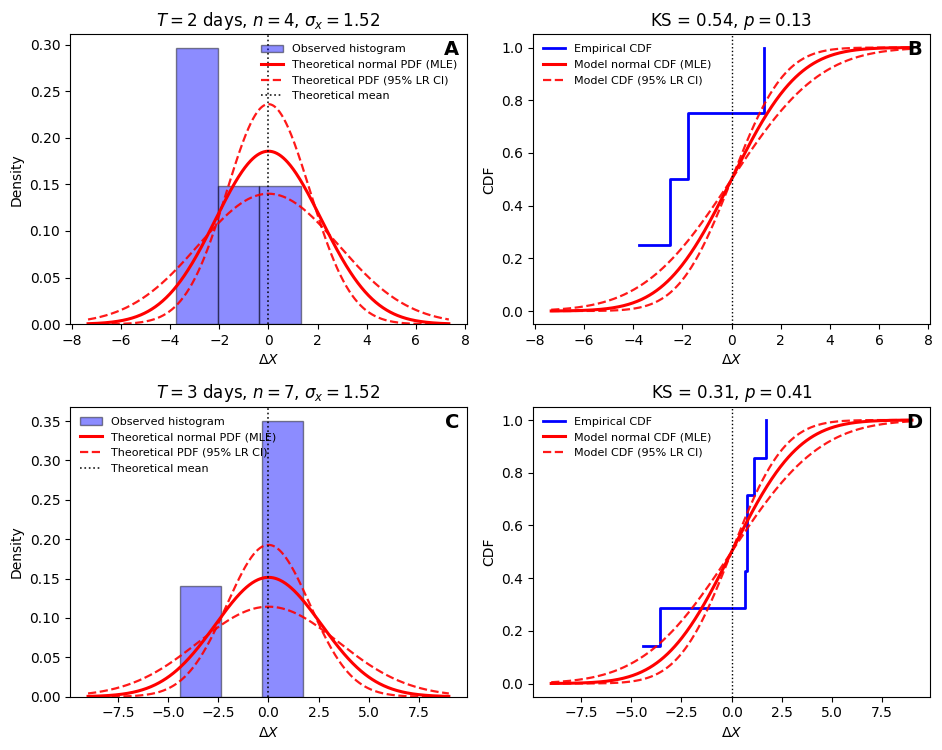

In [8]:
# ============================================================
# Stacked PDF + CDF figure
# Rows = different T values
# Col 1 = histogram vs model PDF
# Col 2 = empirical CDF vs model CDF
# Solid red = MLE sigma_x
# Red dashed = lower/upper 95% LR CI sigma_x
# ============================================================
T_values = np.sort(ks_results_df["T"].unique())
n_rows = len(T_values)
n_cols = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(9.5, 3.8 * n_rows),
    sharey=False
)

# Make axes always 2D if only one row
if n_rows == 1:
    axes = axes.reshape(1, 2)

panel_labels = list(string.ascii_uppercase)
label_i = 0

for i, T_val in enumerate(T_values):
    sub = df_plot[df_plot["T"] == T_val]
    x_obs = sub["dX"].to_numpy(dtype=float)
    x_sorted = np.sort(x_obs)
    n = len(x_obs)

    # Standard deviations for MLE and CI bounds
    sd_mle = sigma_mle * np.sqrt(T_val)
    sd_low = sigma_ci_low * np.sqrt(T_val)
    sd_high = sigma_ci_high * np.sqrt(T_val)

    # x-range for plotting
    x_min = min(
        x_obs.min(),
        stats.norm.ppf(0.005, loc=0, scale=sd_high)
    )
    x_max = max(
        x_obs.max(),
        stats.norm.ppf(0.995, loc=0, scale=sd_high)
    )
    x_grid = np.linspace(x_min, x_max, 500)

    row = ks_results_df[ks_results_df["T"] == T_val].iloc[0]
    ks_stat = row["KS_statistic"]
    p_value = row["p_value"]

    # ========================================================
    # First column: histogram + PDF
    # ========================================================
    ax = axes[i, 0]

    pdf_mle = stats.norm.pdf(x_grid, loc=0, scale=sd_mle)
    pdf_low = stats.norm.pdf(x_grid, loc=0, scale=sd_low)
    pdf_high = stats.norm.pdf(x_grid, loc=0, scale=sd_high)

    ax.hist(
        x_obs,
        bins=3,
        density=True,
        alpha=0.45,
        color="blue",
        edgecolor="black",
        label="Observed histogram"
    )

    ax.plot(
        x_grid,
        pdf_mle,
        color="red",
        linewidth=2.2,
        label="Theoretical normal PDF (MLE)"
    )

    ax.plot(
        x_grid,
        pdf_low,
        color="red",
        linestyle="--",
        linewidth=1.6,
        alpha=0.9,
        label="Theoretical PDF (95% LR CI)"
    )

    ax.plot(
        x_grid,
        pdf_high,
        color="red",
        linestyle="--",
        linewidth=1.6,
        alpha=0.9
    )

    observed_mean = np.mean(x_obs)

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.9,
        label="Theoretical mean"
    )

    ax.set_title(
        rf"$T = {T_val:.3g}$ days, $n = {n}$, $\sigma_x = {sigma_mle:.2f}$"
    )

    ax.set_xlabel(r"$\Delta X$")
    ax.set_ylabel("Density")
    ax.legend(frameon=False, fontsize=8)

    ax.text(
        0.98, 0.98, panel_labels[label_i],
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14, fontweight="bold"
    )
    label_i += 1

    # ========================================================
    # Second column: CDF
    # ========================================================
    ax = axes[i, 1]

    ecdf = np.arange(1, n + 1) / n

    cdf_mle = stats.norm.cdf(x_grid, loc=0, scale=sd_mle)
    cdf_low = stats.norm.cdf(x_grid, loc=0, scale=sd_low)
    cdf_high = stats.norm.cdf(x_grid, loc=0, scale=sd_high)

    ax.step(
        x_sorted,
        ecdf,
        where="post",
        color="blue",
        linewidth=2,
        label="Empirical CDF"
    )

    ax.plot(
        x_grid,
        cdf_mle,
        color="red",
        linewidth=2.2,
        label="Model normal CDF (MLE)"
    )

    ax.plot(
        x_grid,
        cdf_low,
        color="red",
        linestyle="--",
        linewidth=1.6,
        alpha=0.9,
        label="Model CDF (95% LR CI)"
    )

    ax.plot(
        x_grid,
        cdf_high,
        color="red",
        linestyle="--",
        linewidth=1.6,
        alpha=0.9
    )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    ax.set_title(
#        rf"$T = {T_val:.3g}$ days, $n = {n}$" "\n"
        rf"KS = {ks_stat:.2f}, $p = {p_value:.2g}$"
    )

    ax.set_xlabel(r"$\Delta X$")
    ax.set_ylabel("CDF")
    ax.legend(frameon=False, fontsize=8)

    ax.text(
        0.98, 0.98, panel_labels[label_i],
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14, fontweight="bold"
    )
    label_i += 1

plt.tight_layout()
plt.show()

#### Figure S9

In [9]:
# ============================================================
# TonkinHill parameters
# ============================================================

sigma_mle = 1.149153
sigma_ci_low = 0.948326
sigma_ci_high = 1.479084

# ============================================================
# Prepare McCrone data
# ============================================================

df_plot = df_tonkin_drop_zero_common.copy()
df_plot["dX"] = df_plot["X2"] - df_plot["X1"]

df_plot = df_plot.dropna(subset=["T", "dX"]).copy()
df_plot["T"] = df_plot["T"].astype(float)
df_plot["dX"] = df_plot["dX"].astype(float)

T_values = np.sort(df_plot["T"].unique())

# ============================================================
# KS test against Normal(0, sigma_mle^2 T)
# ============================================================

ks_results = []

for T_val, sub in df_plot.groupby("T"):
    x = sub["dX"].to_numpy(dtype=float)

    sd_mle = sigma_mle * np.sqrt(T_val)

    ks_stat, p_value = stats.kstest(
        x,
        "norm",
        args=(0, sd_mle)
    )

    ks_results.append({
        "T": T_val,
        "n": len(x),
        "sigma_mle": sigma_mle,
        "sigma_ci_low": sigma_ci_low,
        "sigma_ci_high": sigma_ci_high,
        "expected_mean_dX": 0.0,
        "observed_mean_dX": np.mean(x),
        "expected_sd_dX_mle": sd_mle,
        "observed_sd_dX": np.std(x, ddof=1) if len(x) > 1 else np.nan,
        "KS_statistic": ks_stat,
        "p_value": p_value
    })

ks_results_df = pd.DataFrame(ks_results).sort_values("T")
ks_results_df = ks_results_df[~ks_results_df["T"].isin([1, 2])].copy()

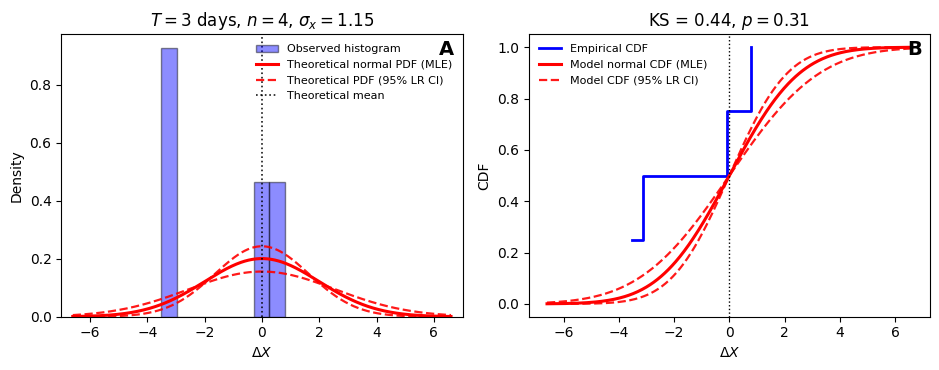

In [10]:
# ============================================================
# Stacked PDF + CDF figure
# Rows = different T values
# Col 1 = histogram vs model PDF
# Col 2 = empirical CDF vs model CDF
# Solid red = MLE sigma_x
# Red dashed = lower/upper 95% LR CI sigma_x
# ============================================================
T_values = np.sort(ks_results_df["T"].unique())
n_rows = len(T_values)
n_cols = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(9.5, 3.8 * n_rows),
    sharey=False
)

# Make axes always 2D if only one row
if n_rows == 1:
    axes = axes.reshape(1, 2)

panel_labels = list(string.ascii_uppercase)
label_i = 0


# Bin number for each row
bin_values = [8, 3]

for i, T_val in enumerate(T_values):
    sub = df_plot[df_plot["T"] == T_val]
    x_obs = sub["dX"].to_numpy(dtype=float)
    x_sorted = np.sort(x_obs)
    n = len(x_obs)

    bins_i = bin_values[i]

    # Standard deviations for MLE and CI bounds
    sd_mle = sigma_mle * np.sqrt(T_val)
    sd_low = sigma_ci_low * np.sqrt(T_val)
    sd_high = sigma_ci_high * np.sqrt(T_val)

    # x-range for plotting
    x_min = min(
        x_obs.min(),
        stats.norm.ppf(0.005, loc=0, scale=sd_high)
    )
    x_max = max(
        x_obs.max(),
        stats.norm.ppf(0.995, loc=0, scale=sd_high)
    )
    x_grid = np.linspace(x_min, x_max, 500)

    row = ks_results_df[ks_results_df["T"] == T_val].iloc[0]
    ks_stat = row["KS_statistic"]
    p_value = row["p_value"]

    # ========================================================
    # First column: histogram + PDF
    # ========================================================
    ax = axes[i, 0]

    pdf_mle = stats.norm.pdf(x_grid, loc=0, scale=sd_mle)
    pdf_low = stats.norm.pdf(x_grid, loc=0, scale=sd_low)
    pdf_high = stats.norm.pdf(x_grid, loc=0, scale=sd_high)

    ax.hist(
        x_obs,
        bins=bins_i,
        density=True,
        alpha=0.45,
        color="blue",
        edgecolor="black",
        label="Observed histogram"
    )

    ax.plot(
        x_grid,
        pdf_mle,
        color="red",
        linewidth=2.2,
        label="Theoretical normal PDF (MLE)"
    )

    ax.plot(
        x_grid,
        pdf_low,
        color="red",
        linestyle="--",
        linewidth=1.6,
        alpha=0.9,
        label="Theoretical PDF (95% LR CI)"
    )

    ax.plot(
        x_grid,
        pdf_high,
        color="red",
        linestyle="--",
        linewidth=1.6,
        alpha=0.9
    )

    observed_mean = np.mean(x_obs)


    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.9,
        label="Theoretical mean"
    )

    ax.set_title(
        rf"$T = {T_val:.3g}$ days, $n = {n}$, $\sigma_x = {sigma_mle:.2f}$"
    )

    ax.set_xlabel(r"$\Delta X$")
    ax.set_ylabel("Density")
    ax.legend(frameon=False, fontsize=8)

    ax.text(
        0.98, 0.98, panel_labels[label_i],
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14, fontweight="bold"
    )
    label_i += 1
    ax.set_xlim(-7, 7)
    # ========================================================
    # Second column: CDF
    # ========================================================
    ax = axes[i, 1]

    ecdf = np.arange(1, n + 1) / n

    cdf_mle = stats.norm.cdf(x_grid, loc=0, scale=sd_mle)
    cdf_low = stats.norm.cdf(x_grid, loc=0, scale=sd_low)
    cdf_high = stats.norm.cdf(x_grid, loc=0, scale=sd_high)

    ax.step(
        x_sorted,
        ecdf,
        where="post",
        color="blue",
        linewidth=2,
        label="Empirical CDF"
    )

    ax.plot(
        x_grid,
        cdf_mle,
        color="red",
        linewidth=2.2,
        label="Model normal CDF (MLE)"
    )

    ax.plot(
        x_grid,
        cdf_low,
        color="red",
        linestyle="--",
        linewidth=1.6,
        alpha=0.9,
        label="Model CDF (95% LR CI)"
    )

    ax.plot(
        x_grid,
        cdf_high,
        color="red",
        linestyle="--",
        linewidth=1.6,
        alpha=0.9
    )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    ax.set_title(
#        rf"$T = {T_val:.3g}$ days, $n = {n}$" "\n"
        rf"KS = {ks_stat:.2f}, $p = {p_value:.2g}$"
    )

    ax.set_xlabel(r"$\Delta X$")
    ax.set_ylabel("CDF")
    ax.legend(frameon=False, fontsize=8)

    ax.text(
        0.98, 0.98, panel_labels[label_i],
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14, fontweight="bold"
    )
    label_i += 1

plt.tight_layout()
plt.show()